In [1]:
import os
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from IPython.display import display
from dotenv import load_dotenv

load_dotenv()

conn = psycopg2.connect(
    host=os.environ.get('DB_HOST', os.environ.get('POSTGRES_HOST', 'localhost')),
    port=os.environ.get('DB_PORT', os.environ.get('POSTGRES_PORT', '5432')),
    user=os.environ.get('DB_USER', os.environ.get('POSTGRES_USER', 'postgres')),
    password=os.environ.get('DB_PASSWORD', os.environ.get('POSTGRES_PASSWORD', 'postgres')),
    dbname=os.environ.get('DB_NAME', os.environ.get('POSTGRES_DB', 'olist'))
)

with open('../../sql/analysis/04_review_score_drivers.sql', 'r') as f:
    sql_script = f.read()

queries = [q + ';' for q in sql_script.split(';') if q.strip()]

df1 = pd.read_sql(queries[0], conn)
df2 = pd.read_sql(queries[1], conn)
df3 = pd.read_sql(queries[2], conn)

display(df1)
display(df2)
display(df3)

/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66188/3082213205.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(queries[0], conn)
/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66188/3082213205.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(queries[1], conn)
/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66188/3082213205.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql(queries[2], conn)


,review_score,total_reviews,pct_of_total
0,5,57328,57.78
1,4,19142,19.29
2,3,8179,8.24
3,2,3151,3.18
4,1,11424,11.51


,delivery_status,total_reviews,avg_review_score
0,Delayed,7700,2.566494
1,On-Time,88661,4.293737


,category_english,total_orders,avg_review_score
0,office_furniture,1263,3.616390
1,fashion_male_clothing,111,3.702703
2,audio,347,3.834294
3,construction_tools_safety,166,3.849398
4,home_confort,395,3.863291
5,fixed_telephony,214,3.901869
6,fashion_underwear_beach,120,3.933333
7,home_construction,487,3.967146
8,bed_bath_table,9313,3.970740
9,telephony,4168,4.003119


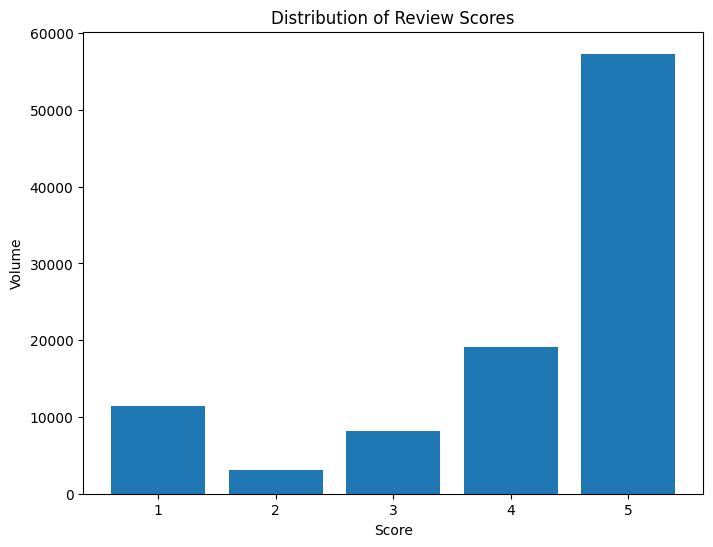

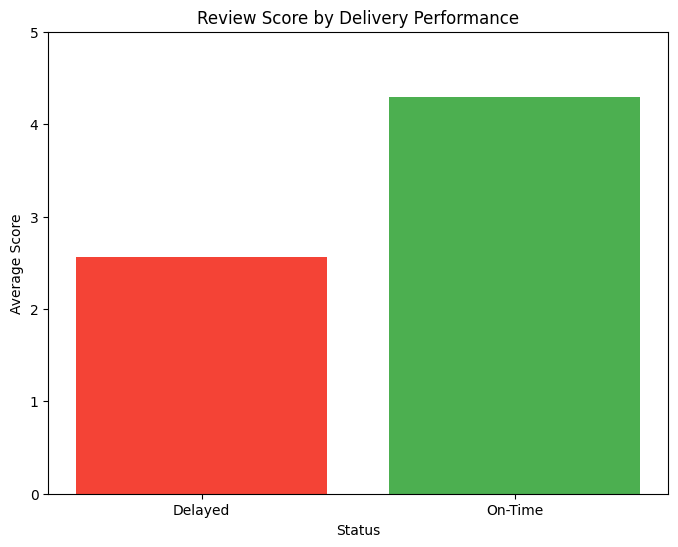

In [2]:
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.bar(df1['review_score'], df1['total_reviews'])
ax1.set_title('Distribution of Review Scores')
ax1.set_xlabel('Score')
ax1.set_ylabel('Volume')
fig1.savefig('../figures/04_score_distribution.png', bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.bar(df2['delivery_status'], df2['avg_review_score'], color=['#F44336', '#4CAF50'])
ax2.set_title('Review Score by Delivery Performance')
ax2.set_xlabel('Status')
ax2.set_ylabel('Average Score')
ax2.set_ylim([0, 5])
fig2.savefig('../figures/04_score_by_delivery.png', bbox_inches='tight')
plt.show()

### Key Findings
- 5-star reviews form the majority, but 1-star reviews represent a significant minority.
- Delayed deliveries strongly correlate with plunging average review scores.